In [1]:
import pandas, urllib, numpy

In [2]:
import statsmodels, statsmodels.stats, statsmodels.stats.multitest

In [3]:
import matplotlib, matplotlib.pyplot
matplotlib.rcParams.update({'font.size':20, 
                            'font.family':'sans-serif', 
                            'xtick.labelsize':16, 
                            'ytick.labelsize':16, 
                            'figure.figsize':(16*(2/3), 9*(2/3)), 
                            'axes.labelsize':20
                           })
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [4]:
# pip install git+https://github.com/Maayanlab/maayanlab-bioinformatics.git
import maayanlab_bioinformatics, maayanlab_bioinformatics.enrichment

# define library

In [5]:
enrichr_library = 'Reactome_Pathways_2024'

# read data

In [6]:
df = pandas.read_csv('029 orsay Table DEGs - particular to VGA.tsv', sep='\t')
original = df['Gene name'].values
gene_list_input = [element.upper() for element in original]
print(len(gene_list_input), gene_list_input[:10])

140 ['CYBRD1', 'C1QTNF3', 'TMEM252', 'GM27029', 'SLFN1', 'PTPN22', 'H2-Q5', 'EPS8L2', 'MS4A4B', 'BC147527']


In [7]:
def get_library(lib_name):
    '''
    Returns a dictionary mapping each term from the input library to 
    its associated geneset. 
    '''
    raw_lib_data = []

    with urllib.request.urlopen('https://maayanlab.cloud/Enrichr/geneSetLibrary?mode=text&libraryName=' + lib_name) as f:
        for line in f.readlines():
            raw_lib_data.append(line.decode("utf-8").split("\t\t"))

    name = []
    gene_list = []
    lib_data = {}

    for i in range(len(raw_lib_data)):
        name += [raw_lib_data[i][0]]
        raw_genes = raw_lib_data[i][1].replace('\t', ' ')
        gene_list += [raw_genes[:-1]]
    
    lib_data = {a[0]:a[1].split(' ') for a in zip(name, gene_list)}
    return lib_data

lib_data = get_library(enrichr_library)

enrich_results = maayanlab_bioinformatics.enrichment.enrich_crisp(gene_list_input, lib_data, 21000, True)

res_df = pandas.DataFrame(
    [ [
        term, 
        res.pvalue, 
        res.odds_ratio,
        res.n_overlap,

    ] for (term, res) in enrich_results ], 
    columns=['term', 'pvalue', 'odds_ratio', 'n_overlap']
)
res_df

,term,pvalue,odds_ratio,n_overlap
0,Adaptive Immune System,0.211705,1.432006,8
1,Anti-inflammatory Response Favouring Leishmani...,0.658471,0.936654,1
2,Antigen Activates B Cell Receptor (BCR) Leadin...,0.474605,1.572510,1
3,Antigen Processing Ubiquitination & Proteasome...,0.864774,0.499806,1
4,Antiviral Mechanism by IFN-stimulated Genes,0.000122,6.896069,7
...,...,...,...,...
252,Vesicle-mediated Transport,0.963047,0.388062,2
253,Viral Infection Pathways,0.546401,1.008136,7
254,ZBP1(DAI) Mediated Induction of Type I IFNs,0.136906,7.139089,1
255,P75 NTR Receptor-Mediated Signalling,0.485091,1.524152,1


In [8]:
# add gene names
container = []
for pathway in res_df['term']:
    
    overlap_genes = []
    for query in lib_data[pathway]:
        if query in gene_list_input:
            overlap_genes.append(query)
    mouse_overlap_genes = [element.lower().title() for element in overlap_genes]
    overlap_genes_string = ', '.join(mouse_overlap_genes)
    container.append(overlap_genes_string)

res_df.loc[:, 'overlap_genes'] = container
res_df

,term,pvalue,odds_ratio,n_overlap,overlap_genes
0,Adaptive Immune System,0.211705,1.432006,8,"Trbc1, Rnf213, Klrk1, Cd274, Cd74, Plcg2, Ptpn..."
1,Anti-inflammatory Response Favouring Leishmani...,0.658471,0.936654,1,Plcg2
2,Antigen Activates B Cell Receptor (BCR) Leadin...,0.474605,1.572510,1,Plcg2
3,Antigen Processing Ubiquitination & Proteasome...,0.864774,0.499806,1,Rnf213
4,Antiviral Mechanism by IFN-stimulated Genes,0.000122,6.896069,7,"Mx1, Mx2, Isg15, Ifit1, Oas2, Oas3, Usp18"
...,...,...,...,...,...
252,Vesicle-mediated Transport,0.963047,0.388062,2,"Gjb3, Tpd52L1"
253,Viral Infection Pathways,0.546401,1.008136,7,"Bst2, Ccr5, Zbp1, Isg15, Plcg2, Ifih1, Oas2"
254,ZBP1(DAI) Mediated Induction of Type I IFNs,0.136906,7.139089,1,Zbp1
255,P75 NTR Receptor-Mediated Signalling,0.485091,1.524152,1,Arhgef4


In [9]:
# multiple test correction
results = statsmodels.stats.multitest.multipletests(res_df['pvalue'], alpha=0.05, method='fdr_bh')
res_df['adjusted'] = results[1]

(248, 6)
(9, 6)
1	1.4325658441967628	Interferon Alpha Beta Signaling	1.225100911240399e-09
2	1.177476984692288	Immune System	9.375100105300863e-07
3	0.8312635123916877	Cytokine Signaling in Immune System	9.375100105300863e-07
4	0.739938591414028	Interferon Signaling	9.375100105300863e-07
5	0.6126413589392592	DAP12 Signaling	0.03315069536190532
6	0.4	Innate Immune System	0.048705573848780874
7	0.3715676273650723	ISG15 Antiviral Mechanism	0.007056882582528529
8	0.252041891903104	Interferon Gamma Signaling	0.020395043918062777


/var/folders/j2/645ctp717nv8rwbn2dsccyxh0000gn/T/ipykernel_3208/3171749573.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  b.loc[:, 'importance'] = importance


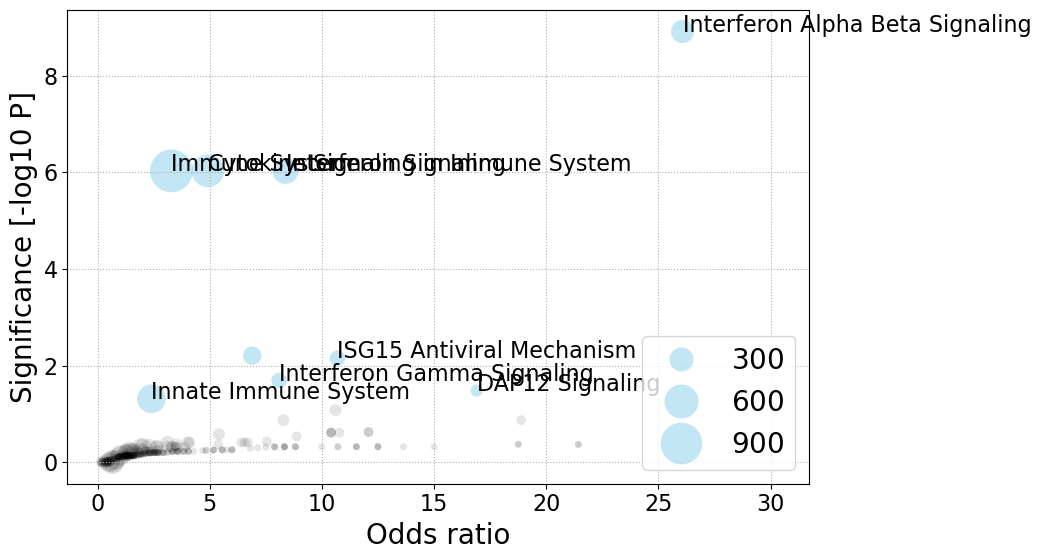

In [10]:
# plot

def importance_calculator(x, y, w):

    xnorm = (x - numpy.min(x)) / (numpy.max(x) - numpy.min(x))
    ynorm = (y - numpy.min(y)) / (numpy.max(y) - numpy.min(y))
    wnorm = (w - numpy.min(w)) / (numpy.max(w) - numpy.min(w))
    
    importance = [numpy.sqrt(xnorm[i]**2 + ynorm[i]**2 + wnorm[i]**2) for i in range(len(x))]
    return importance

inflation = 25

a = res_df[(res_df['adjusted'] > 0.05) | (res_df['odds_ratio'] < 2)]
print(a.shape)
x = a['odds_ratio']
y = -numpy.log10(a['adjusted'])
s = a['n_overlap']
matplotlib.pyplot.scatter(x, y, s*inflation, alpha=1/10, edgecolors='none', color='black')

b = res_df[(res_df['adjusted'] < 0.05) & (res_df['odds_ratio'] > 2)]
print(b.shape)
x = b['odds_ratio']
y = -numpy.log10(b['adjusted'])
s = b['n_overlap']
sc = matplotlib.pyplot.scatter(x, y, s*inflation, alpha=1/2, edgecolors='none', color='skyblue')

x = list(b['odds_ratio'])
y = list(-numpy.log10(b['adjusted']))
prez = list(b['term'].values)
z = [element.split()[-1] for element in prez]
importance = importance_calculator(x, y, s.values)
b.loc[:, 'importance'] = importance
c = b.sort_values('importance', ascending=False)

threshold = importance[numpy.argsort(importance)[::-1][8]] # gimme the top 8
com = c[c['importance'] > threshold]
count = 0
for index, row in com.iterrows():
    x = row['odds_ratio']
    y = -numpy.log10(row['adjusted'])
    
    label = ' '.join(row['term'].split()[:2])
    label = row['term']
    matplotlib.pyplot.text(x, y, label, fontsize=16)
    count = count + 1
    print('{}\t{}\t{}\t{}'.format(count, row['importance'], row['term'], row['adjusted']))

matplotlib.pyplot.legend(*sc.legend_elements("sizes", num=3, color='skyblue', alpha=1/2, mew=0), loc=4)
matplotlib.pyplot.xlabel('Odds ratio')
matplotlib.pyplot.ylabel('Significance [-log10 P]')
matplotlib.pyplot.grid(ls=':', alpha=1)
matplotlib.pyplot.tight_layout()

matplotlib.pyplot.show()
#matplotlib.pyplot.savefig('hom.svg')

In [11]:
# store list 
print(c.shape)
c.drop('pvalue', axis='columns', inplace=True)
d = c.iloc[:, [0, 5, 4, 1, 2, 3]]
d.rename(columns={"term": "Term", 
                  "importance": "Priority", 
                  'adjusted':'Adjusted P', 
                  'odds_ratio':'Odds ratio',
                 'n_overlap':'N overlap',
                 'overlap_genes':'Overlap genes'}, inplace=True)
d.set_index('Term', inplace=True)
d.head()
d.to_csv('particular2vga.wikipathways.tsv', sep='\t')

d

(9, 7)


,Priority,Adjusted P,Odds ratio,N overlap,Overlap genes
Term,,,,,
Interferon Alpha Beta Signaling,1.432566,1.225101e-09,26.072959,11,"Mx1, Mx2, Rsad2, Bst2, Oas2, Oas3, Isg15, Xaf1..."
Immune System,1.177477,9.375100e-07,3.293193,38,"C3Ar1, Rnf213, Cd274, Itgax, Bst2, Plac8, Ifih..."
Cytokine Signaling in Immune System,0.831264,9.375100e-07,4.917434,22,"Gbp6, Muc1, Gbp3, Gbp5, Ccl5, Itgax, Rsad2, Bs..."
Interferon Signaling,0.739939,9.375100e-07,8.378917,14,"Gbp6, Mx1, Mx2, Rsad2, Gbp3, Gbp5, Ifit1, Ifit..."
DAP12 Signaling,0.612641,3.315070e-02,16.896188,3,"Klrd1, Klrk1, Plcg2"
Innate Immune System,0.400000,4.870557e-02,2.406439,17,"C3Ar1, Muc1, Klrk1, Glipr1, Dhx58, Itgax, Bst2..."
ISG15 Antiviral Mechanism,0.371568,7.056883e-03,10.693416,5,"Mx1, Mx2, Isg15, Usp18, Ifit1"
Interferon Gamma Signaling,0.252042,2.039504e-02,8.095517,5,"Gbp6, Gbp3, Gbp5, Oas2, Oas3"
Antiviral Mechanism by IFN-stimulated Genes,0.250587,6.260820e-03,6.896069,7,"Mx1, Mx2, Isg15, Ifit1, Oas2, Oas3, Usp18"
